# OpenCV X-axis Detection with Bar Alignment

Deze notebook detecteert mogelijke x-assen in chart images met OpenCV.

Deze versie gebruikt een betere regel:

> Als meerdere staafdiagrammen dezelfde lijn raken of vanaf dezelfde lijn starten, dan is die lijn waarschijnlijk een as.

Dit werkt beter dan alleen zoeken naar lange horizontale lijnen, omdat jouw afbeeldingen vaak:
- meerdere grafieken in één afbeelding hebben;
- borders/randen bevatten;
- tabelregels bevatten;
- horizontale én verticale bar charts bevatten.

## Idee

Voor verticale staven:

```text
  █   █   █
  █   █   █
────────────  ← x-as
```

De onderkanten van meerdere bars liggen ongeveer op dezelfde y-positie.  
Dus die y-positie is waarschijnlijk de x-as.

Voor horizontale staven:

```text
│ █████
│ ████
│ ██████
↑
as
```

De linker- of rechterkant van meerdere bars ligt ongeveer op dezelfde x-positie.  
Dus die x-positie is waarschijnlijk de as.


In [ ]:
# Run this once if packages are missing
%pip install opencv-python matplotlib numpy pandas

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## 1. Settings

Pas `IMAGE_PATH` aan naar jouw eigen afbeelding.

Voorbeeld:

```python
IMAGE_PATH = Path("../Dataset/Compliant/chart1.png")
```


In [4]:
IMAGE_PATH = Path("../Dataset/Compliant/7.png")

OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Threshold settings
DARK_THRESHOLD = 210
SATURATION_MAX = 110

# Remove outer image frame
BORDER_MARGIN_RATIO = 0.025

# Bar filtering
MIN_BAR_AREA = 80
MIN_BAR_WIDTH = 5
MIN_BAR_HEIGHT = 5
MAX_BAR_THICKNESS_RATIO = 0.45

# Grouping tolerance for aligned bar edges
ALIGNMENT_TOLERANCE = 8

# Minimum bars that need to align to call it an axis
MIN_BARS_ON_AXIS = 2

# Draw settings
MAX_AXES_TO_DRAW = 20

## 2. Helper functions

In [5]:

def show_image(title, image, figsize=(12, 8), cmap=None):
    plt.figure(figsize=figsize)
    if len(image.shape) == 2:
        plt.imshow(image, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def load_image(path):
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def create_chart_element_mask(image):
    """
    Keeps dark/grey chart elements such as bars, axes and text.
    It removes many colored objects by filtering saturation.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    saturation = hsv[:, :, 1]

    dark = gray < DARK_THRESHOLD
    low_saturation = saturation < SATURATION_MAX

    mask = np.zeros_like(gray, dtype=np.uint8)
    mask[dark & low_saturation] = 255

    # Slightly close gaps inside bars
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    return mask


def remove_outer_border(mask):
    h, w = mask.shape[:2]
    mx = int(w * BORDER_MARGIN_RATIO)
    my = int(h * BORDER_MARGIN_RATIO)

    cleaned = mask.copy()
    cleaned[:my, :] = 0
    cleaned[h-my:, :] = 0
    cleaned[:, :mx] = 0
    cleaned[:, w-mx:] = 0

    return cleaned


def detect_bar_candidates(mask):
    """
    Detects rectangle-like components that may be bars.
    This does not need to be perfect. It only needs enough bar candidates
    to estimate common baseline positions.
    """
    h, w = mask.shape[:2]

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bars = []

    for contour in contours:
        x, y, bw, bh = cv2.boundingRect(contour)
        area = bw * bh

        if area < MIN_BAR_AREA:
            continue
        if bw < MIN_BAR_WIDTH or bh < MIN_BAR_HEIGHT:
            continue

        # Ignore very large objects that are probably the whole frame or table regions
        if bw > w * 0.90 or bh > h * 0.90:
            continue

        # Ignore objects very close to full image border
        margin_x = int(w * BORDER_MARGIN_RATIO)
        margin_y = int(h * BORDER_MARGIN_RATIO)
        if x <= margin_x or y <= margin_y or x + bw >= w - margin_x or y + bh >= h - margin_y:
            continue

        aspect = bw / max(bh, 1)

        # Rough classification:
        # vertical bar = taller than wide
        # horizontal bar = wider than tall
        if bh > bw * 1.2:
            bar_type = "vertical_bar"
        elif bw > bh * 1.2:
            bar_type = "horizontal_bar"
        else:
            # square-ish components are often text/symbols, not bars
            continue

        bars.append({
            "x": int(x),
            "y": int(y),
            "w": int(bw),
            "h": int(bh),
            "x_left": int(x),
            "x_right": int(x + bw),
            "y_top": int(y),
            "y_bottom": int(y + bh),
            "area": int(area),
            "aspect": float(aspect),
            "type": bar_type
        })

    return bars


def group_positions(values, tolerance=8):
    """
    Groups close positions together.
    Example: y_bottom values [310, 312, 309] become one group around 310.
    """
    if not values:
        return []

    values = sorted(values)
    groups = [[values[0]]]

    for value in values[1:]:
        if abs(value - np.mean(groups[-1])) <= tolerance:
            groups[-1].append(value)
        else:
            groups.append([value])

    return groups


def find_axes_from_bar_alignment(bars, image_shape):
    """
    Finds possible axes based on aligned edges of bars.

    For vertical bars:
    - aligned y_bottom = likely horizontal x-axis

    For horizontal bars:
    - aligned x_left or x_right = likely vertical axis
    """
    h, w = image_shape[:2]
    candidates = []

    vertical_bars = [b for b in bars if b["type"] == "vertical_bar"]
    horizontal_bars = [b for b in bars if b["type"] == "horizontal_bar"]

    # Horizontal x-axis from bottom edges of vertical bars
    bottom_values = [b["y_bottom"] for b in vertical_bars]
    bottom_groups = group_positions(bottom_values, ALIGNMENT_TOLERANCE)

    for group in bottom_groups:
        if len(group) < MIN_BARS_ON_AXIS:
            continue

        y_axis = int(np.mean(group))
        related_bars = [b for b in vertical_bars if abs(b["y_bottom"] - y_axis) <= ALIGNMENT_TOLERANCE]

        x1 = min(b["x_left"] for b in related_bars)
        x2 = max(b["x_right"] for b in related_bars)

        # Extend line slightly to look like an axis
        pad = int((x2 - x1) * 0.10)
        x1 = max(0, x1 - pad)
        x2 = min(w - 1, x2 + pad)

        candidates.append({
            "orientation": "horizontal_axis_from_vertical_bars",
            "x1": int(x1),
            "y1": int(y_axis),
            "x2": int(x2),
            "y2": int(y_axis),
            "supporting_bars": len(related_bars),
            "score": float((x2 - x1) + len(related_bars) * 60)
        })

    # Vertical axis from left edges of horizontal bars
    left_values = [b["x_left"] for b in horizontal_bars]
    left_groups = group_positions(left_values, ALIGNMENT_TOLERANCE)

    for group in left_groups:
        if len(group) < MIN_BARS_ON_AXIS:
            continue

        x_axis = int(np.mean(group))
        related_bars = [b for b in horizontal_bars if abs(b["x_left"] - x_axis) <= ALIGNMENT_TOLERANCE]

        y1 = min(b["y_top"] for b in related_bars)
        y2 = max(b["y_bottom"] for b in related_bars)

        pad = int((y2 - y1) * 0.10)
        y1 = max(0, y1 - pad)
        y2 = min(h - 1, y2 + pad)

        candidates.append({
            "orientation": "vertical_axis_from_horizontal_bars_left",
            "x1": int(x_axis),
            "y1": int(y1),
            "x2": int(x_axis),
            "y2": int(y2),
            "supporting_bars": len(related_bars),
            "score": float((y2 - y1) + len(related_bars) * 60)
        })

    # Vertical axis from right edges of horizontal bars
    # Useful for diverging bars or charts where bars extend left.
    right_values = [b["x_right"] for b in horizontal_bars]
    right_groups = group_positions(right_values, ALIGNMENT_TOLERANCE)

    for group in right_groups:
        if len(group) < MIN_BARS_ON_AXIS:
            continue

        x_axis = int(np.mean(group))
        related_bars = [b for b in horizontal_bars if abs(b["x_right"] - x_axis) <= ALIGNMENT_TOLERANCE]

        y1 = min(b["y_top"] for b in related_bars)
        y2 = max(b["y_bottom"] for b in related_bars)

        pad = int((y2 - y1) * 0.10)
        y1 = max(0, y1 - pad)
        y2 = min(h - 1, y2 + pad)

        candidates.append({
            "orientation": "vertical_axis_from_horizontal_bars_right",
            "x1": int(x_axis),
            "y1": int(y1),
            "x2": int(x_axis),
            "y2": int(y2),
            "supporting_bars": len(related_bars),
            "score": float((y2 - y1) + len(related_bars) * 60)
        })

    candidates = sorted(candidates, key=lambda c: c["score"], reverse=True)
    return candidates


def draw_bars_and_axes(image, bars, axes, max_axes=20):
    output = image.copy()

    # Draw bars in orange
    for b in bars:
        x, y, bw, bh = b["x"], b["y"], b["w"], b["h"]
        cv2.rectangle(output, (x, y), (x + bw, y + bh), (0, 165, 255), 1)

    # Draw axes
    for i, axis in enumerate(axes[:max_axes], start=1):
        x1, y1, x2, y2 = axis["x1"], axis["y1"], axis["x2"], axis["y2"]

        if "horizontal" in axis["orientation"]:
            color = (0, 180, 0)
            label = f"X{i} bars={axis['supporting_bars']}"
            label_pos = (x1, max(15, y1 - 8))
        else:
            color = (255, 0, 0)
            label = f"V{i} bars={axis['supporting_bars']}"
            label_pos = (x1 + 5, max(15, y1 + 15))

        cv2.line(output, (x1, y1), (x2, y2), color, 3)
        cv2.putText(output, label, label_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    return output


def axes_to_dataframe(axes):
    rows = []
    for i, a in enumerate(axes, start=1):
        rows.append({
            "rank": i,
            "orientation": a["orientation"],
            "x1": a["x1"],
            "y1": a["y1"],
            "x2": a["x2"],
            "y2": a["y2"],
            "supporting_bars": a["supporting_bars"],
            "score": round(a["score"], 1)
        })
    return pd.DataFrame(rows)


def run_bar_alignment_detection(image):
    mask = create_chart_element_mask(image)
    cleaned = remove_outer_border(mask)
    bars = detect_bar_candidates(cleaned)
    axes = find_axes_from_bar_alignment(bars, image.shape)

    return {
        "mask": mask,
        "cleaned_mask": cleaned,
        "bars": bars,
        "axes": axes
    }


## 3. Run detection on one image

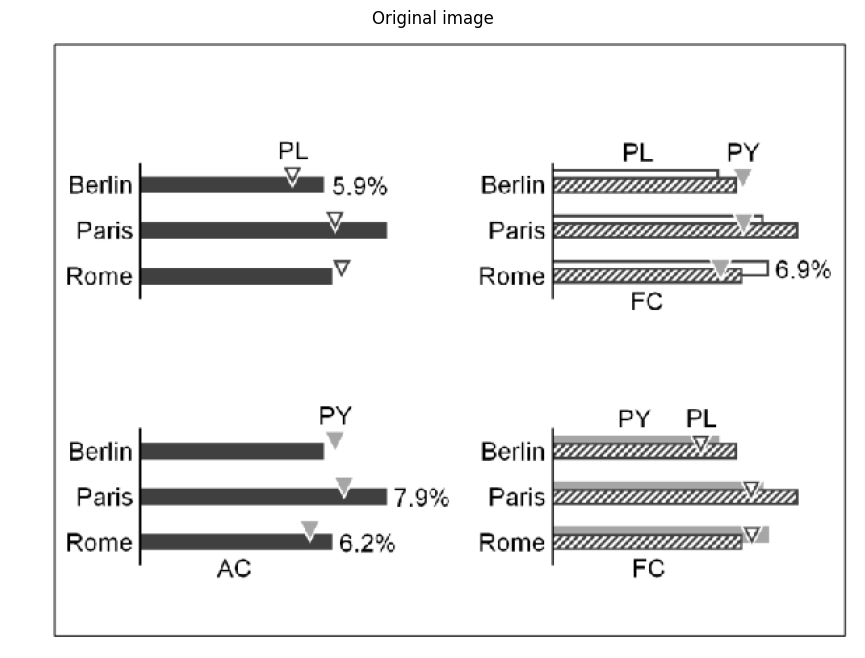

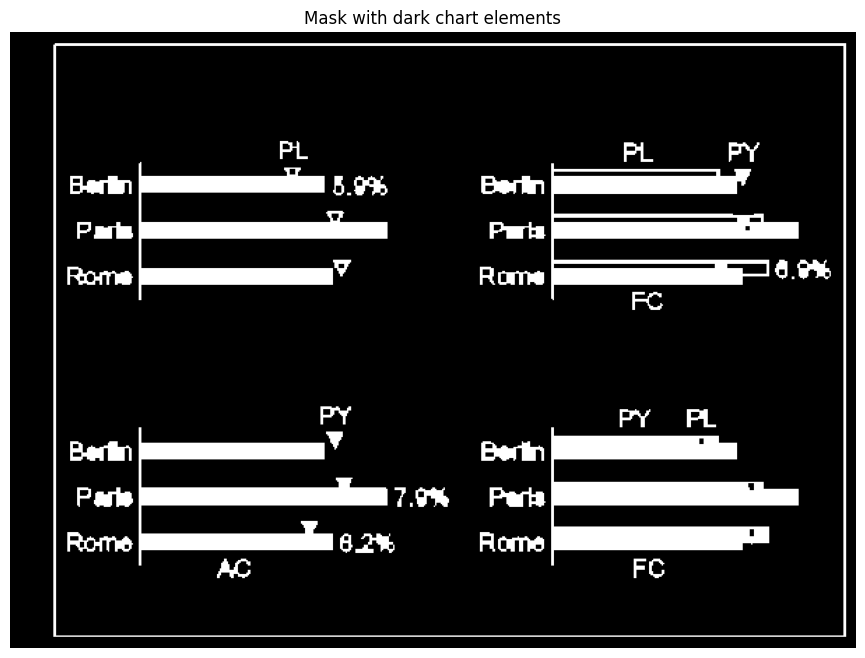

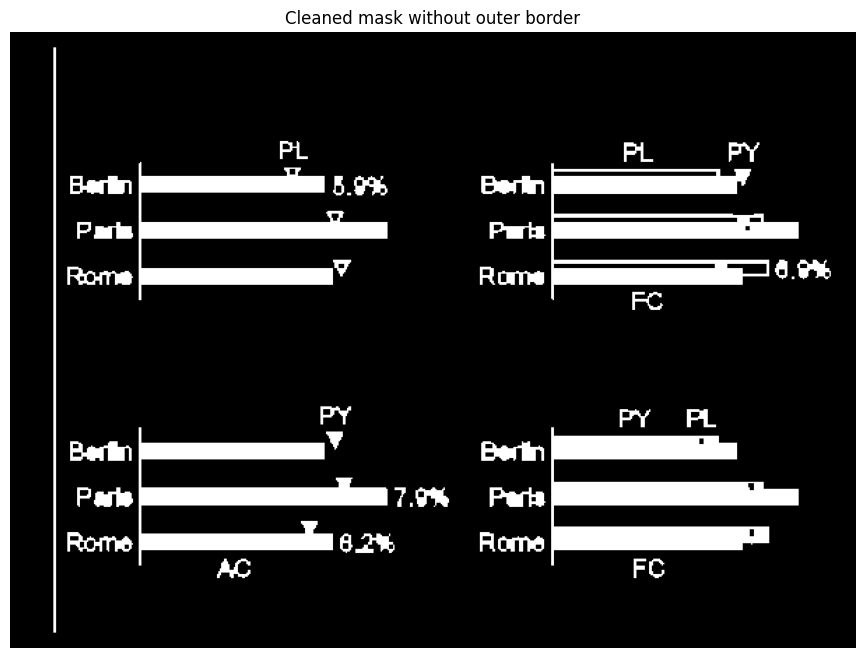

Detected bar candidates: 36
Detected axis candidates: 16


In [6]:
image = load_image(IMAGE_PATH)
show_image("Original image", image)

result = run_bar_alignment_detection(image)

show_image("Mask with dark chart elements", result["mask"])
show_image("Cleaned mask without outer border", result["cleaned_mask"])

print("Detected bar candidates:", len(result["bars"]))
print("Detected axis candidates:", len(result["axes"]))

## 4. Show final result

Oranje boxes = gevonden bar-kandidaten  
Groen = horizontale x-as op basis van verticale bars  
Blauw = verticale as op basis van horizontale bars


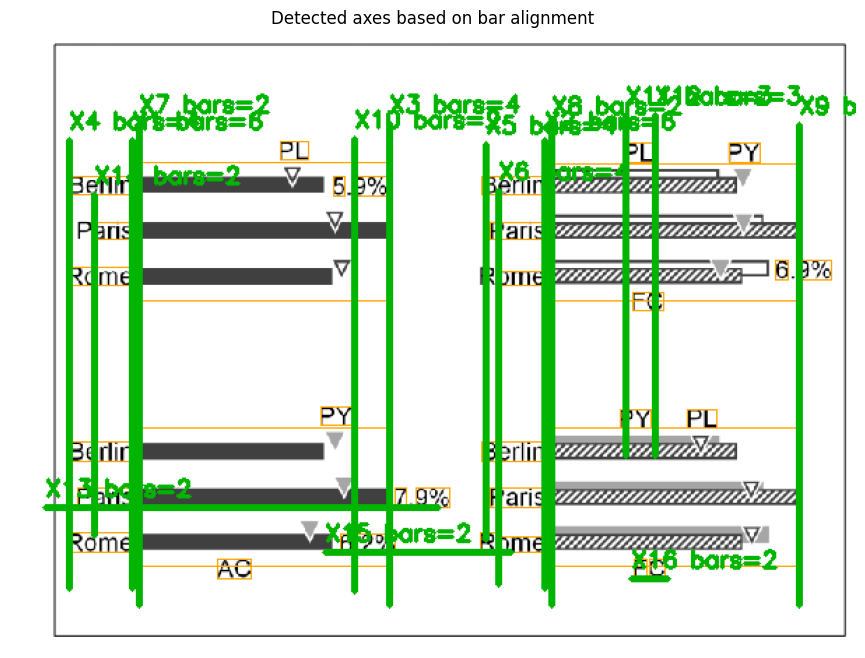

Saved to: ..\output\7_bar_alignment_axes.png


In [7]:
output = draw_bars_and_axes(image, result["bars"], result["axes"], max_axes=MAX_AXES_TO_DRAW)
show_image("Detected axes based on bar alignment", output)

output_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_bar_alignment_axes.png"
cv2.imwrite(str(output_path), output)
print("Saved to:", output_path)

## 5. Axis coordinates

In [ ]:
axes_df = axes_to_dataframe(result["axes"])
axes_df

## 6. Batch test on the whole dataset

Deze cel test automatisch alle afbeeldingen in:

```text
Dataset/Compliant
Dataset/Non-Compliant
```

De resultaten worden opgeslagen in:

```text
output/bar_alignment_batch_results
```


In [ ]:
DATASET_DIR = Path("../Dataset")
BATCH_OUTPUT_DIR = OUTPUT_DIR / "bar_alignment_batch_results"
BATCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

image_extensions = [".png", ".jpg", ".jpeg", ".webp"]
image_paths = []

for ext in image_extensions:
    image_paths.extend(DATASET_DIR.rglob(f"*{ext}"))

print("Found images:", len(image_paths))

summary_rows = []

for path in image_paths:
    try:
        img = load_image(path)
        res = run_bar_alignment_detection(img)
        out = draw_bars_and_axes(img, res["bars"], res["axes"], max_axes=MAX_AXES_TO_DRAW)

        relative = path.relative_to(DATASET_DIR)
        save_path = BATCH_OUTPUT_DIR / relative
        save_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(save_path), out)

        summary_rows.append({
            "image": str(relative),
            "bar_candidates": len(res["bars"]),
            "axis_candidates": len(res["axes"]),
            "best_axis_supporting_bars": res["axes"][0]["supporting_bars"] if res["axes"] else 0,
            "output": str(save_path)
        })

        print("Saved:", save_path)

    except Exception as e:
        print("Error with", path, ":", e)

summary_df = pd.DataFrame(summary_rows)
summary_df

## 7. Explanation for the assignment

You can use this text:

> This notebook uses a rule-based OpenCV approach to detect possible x-axes in chart images. Instead of only searching for long horizontal lines, the method also analyses the alignment of bar shapes. The main assumption is that if multiple bars start or end on the same line, that line is likely to be an axis. First, dark and low-saturation chart elements are extracted from the image. Then possible bar shapes are detected using contours and bounding boxes. For vertical bar charts, the algorithm groups the bottom edges of bars; if multiple bottom edges align, a horizontal x-axis candidate is created. For horizontal bar charts, the algorithm groups the left and right edges of bars; if multiple edges align, a vertical axis candidate is created. The final output contains the coordinates of possible axes and the number of bars supporting each axis.

Limitation:

> This approach does not train an AI model. It is a rule-based computer vision pipeline. It works best when the bars are clearly visible and multiple bars share the same baseline. In complex charts, some non-bar elements may still be detected as bar candidates, so the output should be evaluated visually.
